<a href="https://colab.research.google.com/github/jayden14141/Network-Anomaly-Detection/blob/main/ml/notebooks/06_evaluation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import json
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 100

try:
    from google.colab import drive
    drive.mount('/content/drive', force_remount=True)
    BASE = '/content/drive/MyDrive'
    with open(f'{BASE}/results_large.json') as f:
        results_large = json.load(f)
    with open(f'{BASE}/results_medium.json') as f:
        results_medium = json.load(f)
    with open(f'{BASE}/results_small.json') as f:
        results_small = json.load(f)
    with open(f'{BASE}/attack_groups.json') as f:
        groups = json.load(f)
    print("Loaded all results.")
except Exception as e:
    print(f"Load failed: {e}")

Mounted at /content/drive
Loaded all results.


In [2]:
def flatten(results_dict, group_name):
    rows = []
    for attack, models in results_dict.items():
        for model, s in models.items():
            row = {
                'Group': group_name,
                'Attack': attack,
                'Model': model,
                'CV Recall Mean': s.get('cv_recall_mean'),
                'CV Recall Std': s.get('cv_recall_std'),
                'Test Recall': s['test_recall'],
                'Test Precision': s['test_precision'],
                'Test F1': s['test_f1'],
                'Time(s)': s['elapsed_sec'],
                'n_attack_train': s.get('n_attack_train'),
                'n_attack_test': s.get('n_attack_test'),
            }
            rows.append(row)
    return rows

all_rows = (
    flatten(results_large, 'large') +
    flatten(results_medium, 'medium') +
    flatten(results_small, 'small')
)
master = pd.DataFrame(all_rows)
print(f"Master table: {master.shape}")
master.head(8)

Master table: (56, 11)


,Group,Attack,Model,CV Recall Mean,CV Recall Std,Test Recall,Test Precision,Test F1,Time(s),n_attack_train,n_attack_test
0,large,DoS Hulk,RF,0.999375,0.000141,0.9994,0.955906,0.977169,179.4,NaN,NaN
1,large,DoS Hulk,XGBoost,0.999500,0.000177,0.9992,0.955532,0.976878,14.7,NaN,NaN
2,large,DoS Hulk,LightGBM,0.999450,0.000197,0.9993,0.955902,0.977119,17.2,NaN,NaN
3,large,DoS Hulk,AE,0.658425,0.012026,0.6324,0.714899,0.671124,112.0,NaN,NaN
4,large,PortScan,RF,0.999575,0.000255,0.9997,0.996710,0.998203,160.4,NaN,NaN
5,large,PortScan,XGBoost,0.999650,0.000197,0.9997,0.996511,0.998103,15.7,NaN,NaN
6,large,PortScan,LightGBM,0.999750,0.000154,0.9997,0.996809,0.998253,17.6,NaN,NaN
7,large,PortScan,AE,0.015525,0.008487,0.0009,0.003395,0.001423,119.8,NaN,NaN


In [3]:
group_order = {'large': 0, 'medium': 1, 'small': 2}
master['_group_order'] = master['Group'].map(group_order)
display_df = master.sort_values(
    ['_group_order', 'Attack', 'Test Recall'],
    ascending=[True, True, False]
).drop(columns='_group_order')

display_df_formatted = display_df.copy()
display_df_formatted['CV Recall'] = display_df_formatted.apply(
    lambda r: f"{r['CV Recall Mean']:.3f}±{r['CV Recall Std']:.3f}"
              if pd.notna(r['CV Recall Mean']) else "N/A",
    axis=1
)
display_df_formatted = display_df_formatted[
    ['Group', 'Attack', 'Model', 'CV Recall', 'Test Recall', 'Test Precision', 'Test F1', 'Time(s)']
]
display_df_formatted[['Test Recall', 'Test Precision', 'Test F1']] = \
    display_df_formatted[['Test Recall', 'Test Precision', 'Test F1']].round(3)

print(display_df_formatted.to_string(index=False))
display_df_formatted.to_csv(f'{BASE}/master_results.csv', index=False)
print(f"\nSaved: master_results.csv")

 Group                     Attack    Model   CV Recall  Test Recall  Test Precision  Test F1  Time(s)
 large                       DDoS       RF 0.998±0.000        0.998           0.998    0.998     78.2
 large                       DDoS  XGBoost 0.998±0.000        0.998           0.997    0.997     13.6
 large                       DDoS LightGBM 0.998±0.000        0.998           0.997    0.997     17.0
 large                       DDoS       AE 0.173±0.002        0.173           0.404    0.242    104.3
 large              DoS GoldenEye  XGBoost 0.999±0.001        1.000           0.991    0.995      3.6
 large              DoS GoldenEye LightGBM 0.998±0.001        0.999           0.992    0.995      3.6
 large              DoS GoldenEye       RF 0.995±0.001        0.997           0.995    0.996     38.3
 large              DoS GoldenEye       AE 0.884±0.008        0.703           0.729    0.716     28.7
 large                   DoS Hulk       RF 0.999±0.000        0.999           0.95

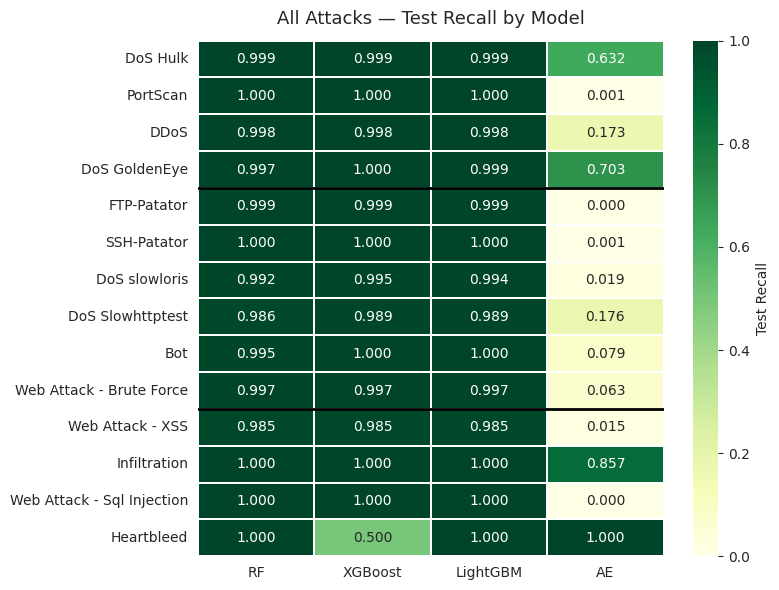

In [4]:
all_attacks = groups['large'] + groups['medium'] + groups['small']
all_models = ['RF', 'XGBoost', 'LightGBM', 'AE']

heatmap_data = pd.DataFrame(index=all_attacks, columns=all_models, dtype=float)
for _, row in master.iterrows():
    heatmap_data.loc[row['Attack'], row['Model']] = row['Test Recall']

fig, ax = plt.subplots(figsize=(8, max(6, len(all_attacks) * 0.4)))
sns.heatmap(heatmap_data, annot=True, fmt='.3f', cmap='YlGn',
            vmin=0, vmax=1, cbar_kws={'label': 'Test Recall'}, ax=ax,
            linewidths=0.3, linecolor='white')

# Group separators
group_boundaries = [len(groups['large']), len(groups['large']) + len(groups['medium'])]
for b in group_boundaries:
    ax.axhline(b, color='black', linewidth=2)

ax.set_title('All Attacks — Test Recall by Model', pad=12, fontsize=13)
plt.tight_layout()
plt.savefig(f'{BASE}/final_recall_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

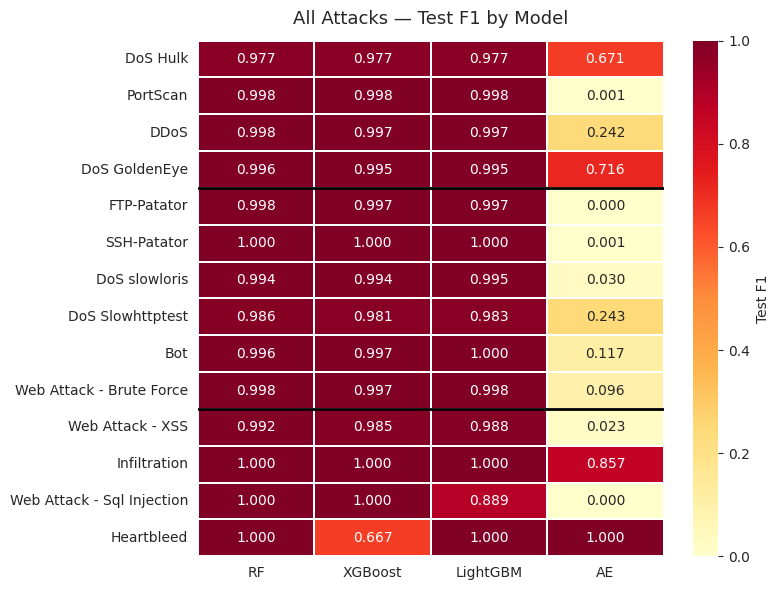

In [5]:
heatmap_f1 = pd.DataFrame(index=all_attacks, columns=all_models, dtype=float)
for _, row in master.iterrows():
    heatmap_f1.loc[row['Attack'], row['Model']] = row['Test F1']

fig, ax = plt.subplots(figsize=(8, max(6, len(all_attacks) * 0.4)))
sns.heatmap(heatmap_f1, annot=True, fmt='.3f', cmap='YlOrRd',
            vmin=0, vmax=1, cbar_kws={'label': 'Test F1'}, ax=ax,
            linewidths=0.3, linecolor='white')
for b in group_boundaries:
    ax.axhline(b, color='black', linewidth=2)
ax.set_title('All Attacks — Test F1 by Model', pad=12, fontsize=13)
plt.tight_layout()
plt.savefig(f'{BASE}/final_f1_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

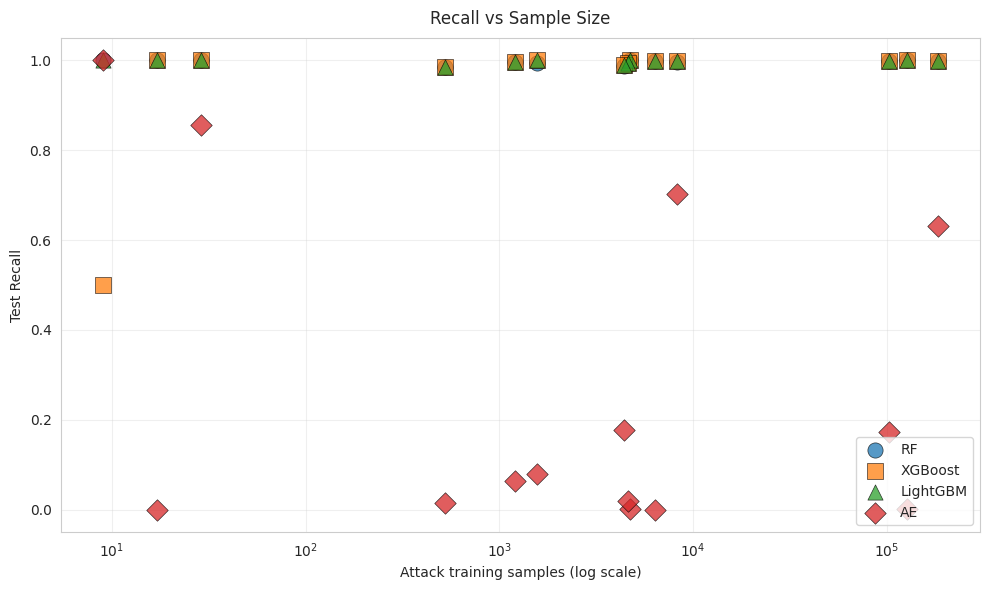

In [6]:
# Use attack count from full df for x-axis (more reliable than n_attack_train)
attack_counts = {}
for grp_results in [results_large, results_medium, results_small]:
    for attack, models in grp_results.items():
        # Use any model's n_attack_train; if missing (large/medium), reconstruct from group
        sample = next(iter(models.values()))
        n = sample.get('n_attack_train')
        attack_counts[attack] = n

# For large/medium where n_attack_train isn't recorded, recompute from data?
# Simpler: just use what we have and skip missing
plot_data = master[['Attack', 'Model', 'Test Recall', 'n_attack_train']].dropna()

# If n_attack_train missing for large/medium, fill from raw df
if plot_data.shape[0] < master.shape[0]:
    # we'll need the cleaned df; skip if not loaded
    try:
        df = pd.read_csv(f'{BASE}/cicids2017_cleaned.csv')
        for idx, row in master.iterrows():
            if pd.isna(row['n_attack_train']):
                # rough estimate: 80% of total attack count
                total = (df['Label'] == row['Attack']).sum()
                master.at[idx, 'n_attack_train'] = int(total * 0.8)
        plot_data = master[['Attack', 'Model', 'Test Recall', 'n_attack_train']]
    except Exception as e:
        print(f"Could not fill missing counts: {e}")

fig, ax = plt.subplots(figsize=(10, 6))
markers = {'RF': 'o', 'XGBoost': 's', 'LightGBM': '^', 'AE': 'D'}
colors = {'RF': '#1f77b4', 'XGBoost': '#ff7f0e', 'LightGBM': '#2ca02c', 'AE': '#d62728'}

for model in all_models:
    sub = plot_data[plot_data['Model'] == model]
    ax.scatter(sub['n_attack_train'], sub['Test Recall'],
               s=120, marker=markers[model], color=colors[model],
               label=model, alpha=0.75, edgecolors='black', linewidths=0.5)

ax.set_xscale('log')
ax.set_xlabel('Attack training samples (log scale)')
ax.set_ylabel('Test Recall')
ax.set_title('Recall vs Sample Size', pad=10)
ax.set_ylim(-0.05, 1.05)
ax.legend(loc='lower right')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(f'{BASE}/recall_vs_samples.png', dpi=150, bbox_inches='tight')
plt.show()

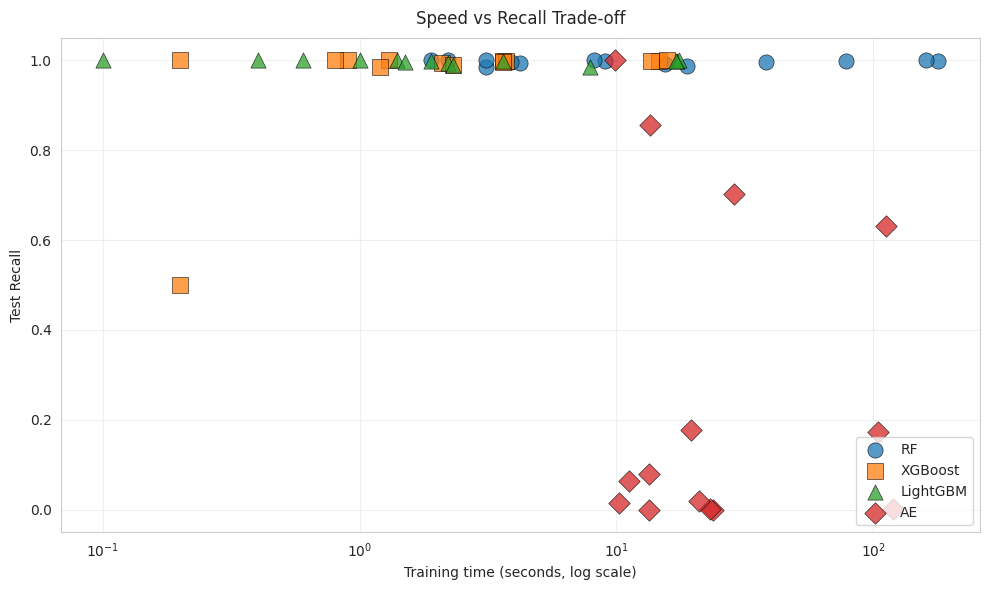

In [7]:
fig, ax = plt.subplots(figsize=(10, 6))
for model in all_models:
    sub = master[master['Model'] == model]
    ax.scatter(sub['Time(s)'], sub['Test Recall'],
               s=120, marker=markers[model], color=colors[model],
               label=model, alpha=0.75, edgecolors='black', linewidths=0.5)

ax.set_xscale('log')
ax.set_xlabel('Training time (seconds, log scale)')
ax.set_ylabel('Test Recall')
ax.set_title('Speed vs Recall Trade-off', pad=10)
ax.set_ylim(-0.05, 1.05)
ax.legend(loc='lower right')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(f'{BASE}/speed_vs_recall.png', dpi=150, bbox_inches='tight')
plt.show()

In [8]:
print("=== Model-level summary (across all attacks) ===\n")
agg = master.groupby('Model').agg({
    'Test Recall': ['mean', 'std'],
    'Test Precision': ['mean', 'std'],
    'Test F1': ['mean', 'std'],
    'Time(s)': 'mean',
}).round(3)
print(agg)

print("\n=== Group × Model recall summary ===\n")
group_agg = master.groupby(['Group', 'Model'])['Test Recall'].agg(['mean', 'std']).round(3)
print(group_agg)

=== Model-level summary (across all attacks) ===

         Test Recall        Test Precision        Test F1        Time(s)
                mean    std           mean    std    mean    std    mean
Model                                                                   
AE             0.266  0.363          0.332  0.356   0.286  0.361  37.414
LightGBM       0.997  0.005          0.979  0.053   0.987  0.029   5.336
RF             0.996  0.005          0.994  0.012   0.995  0.007  37.593
XGBoost        0.961  0.133          0.991  0.013   0.970  0.088   4.564

=== Group × Model recall summary ===

                  mean    std
Group  Model                 
large  AE        0.377  0.344
       LightGBM  0.999  0.001
       RF        0.998  0.001
       XGBoost   0.999  0.001
medium AE        0.056  0.067
       LightGBM  0.997  0.004
       RF        0.995  0.005
       XGBoost   0.997  0.004
small  AE        0.468  0.535
       LightGBM  0.996  0.008
       RF        0.996  0.008
       XGB

In [9]:
best_per_attack = master.loc[master.groupby('Attack')['Test Recall'].idxmax()]
best_per_attack = best_per_attack[['Group', 'Attack', 'Model', 'Test Recall', 'Test F1', 'Time(s)']]
best_per_attack = best_per_attack.sort_values(['Group', 'Attack'])
print("=== Best model per attack (by recall) ===\n")
print(best_per_attack.to_string(index=False))

print(f"\n=== Best model frequency ===")
print(best_per_attack['Model'].value_counts())

=== Best model per attack (by recall) ===

 Group                     Attack   Model  Test Recall  Test F1  Time(s)
 large                       DDoS      RF     0.997800 0.997750     78.2
 large              DoS GoldenEye XGBoost     0.999514 0.995405      3.6
 large                   DoS Hulk      RF     0.999400 0.977169    179.4
 large                   PortScan      RF     0.999700 0.998203    160.4
medium                        Bot XGBoost     1.000000 0.997449      0.9
medium           DoS Slowhttptest XGBoost     0.989091 0.981064      2.3
medium              DoS slowloris XGBoost     0.994823 0.993966      2.1
medium                FTP-Patator      RF     0.999370 0.998426      9.0
medium                SSH-Patator      RF     1.000000 1.000000      8.2
medium   Web Attack - Brute Force      RF     0.996678 0.998336      3.9
 small                 Heartbleed      RF     1.000000 1.000000      1.9
 small               Infiltration      RF     1.000000 1.000000      3.1
 small W

In [10]:
print("=== Small-attack caveat ===\n")
small_caveat = master[master['Group'] == 'small'][
    ['Attack', 'Model', 'n_attack_test', 'Test Recall', 'Test F1']
].dropna()
print(small_caveat.to_string(index=False))
print("\nNOTE: Small attacks with n_attack_test < 10 should be interpreted cautiously.")
print("F1 = 1.0 on a 2-sample test set is statistically uninformative.")

=== Small-attack caveat ===

                    Attack    Model  n_attack_test  Test Recall  Test F1
          Web Attack - XSS       RF          130.0     0.984615 0.992248
          Web Attack - XSS  XGBoost          130.0     0.984615 0.984615
          Web Attack - XSS LightGBM          130.0     0.984615 0.988417
          Web Attack - XSS       AE          130.0     0.015385 0.023121
              Infiltration       RF            7.0     1.000000 1.000000
              Infiltration  XGBoost            7.0     1.000000 1.000000
              Infiltration LightGBM            7.0     1.000000 1.000000
              Infiltration       AE            7.0     0.857143 0.857143
Web Attack - Sql Injection       RF            4.0     1.000000 1.000000
Web Attack - Sql Injection  XGBoost            4.0     1.000000 1.000000
Web Attack - Sql Injection LightGBM            4.0     1.000000 0.888889
Web Attack - Sql Injection       AE            4.0     0.000000 0.000000
                Heartb